# 04 – Gravity-Darkened Transit Modelling with STARRY

## Purpose

This notebook implements the gravity-darkened transit model using the **STARRY** package. It generates synthetic transit light curves for HAT-P-70 and explores how stellar rotation, oblateness, gravity darkening, and spin–orbit geometry affect the observed transit.

> **Compatibility Note**
>
> This notebook was developed using the software environment available on the University College London Observatory (UCLO) machines. The version of **STARRY** used during this research project is not directly compatible with many modern Python environments. Consequently, this notebook may require the original UCLO software environment, or equivalent package versions, to execute successfully.
>
> The notebook is included to document the methodology and implementation used during this MSc research project.

In [21]:
import matplotlib.pyplot as plt
import starry
import numpy as np
#import theano

In [22]:
import sys; print(sys.executable)

/ulo/apps64/Anaconda3-2021.11_starry/bin/python


In [23]:
!conda list starry

# packages in environment at /ulo/apps64/Anaconda3-2021.11_starry:
#
# Name                    Version                   Build  Channel
starry                    1.2.0                    pypi_0    pypi


In [24]:
starry.config.lazy=False
starry.config.quiet=True

In [46]:
# Creating a star
star = starry.Primary(
    map = starry.Map(
        ydeg = 0,
        udeg = 2,
        oblate = True,
        gdeg = 4,
        tpole = 8670,  
        wav = 736,
    ),
    r = 2.075,            # Radius of Star
    m = 1.900             # Mass of Star
)
star.map[1] = 0.1870      # limb-darkening u1
star.map[2] = 0.2672      # limb-darkening u2
star.map.beta = 0.23      # gravity-darkening parameter
star.map.inc = 38.75         # set the star-rotational inclination 
star.map.f = 0.0700       # oblatness (~ 0.330 limit)

# Creating a planet
planet = starry.Secondary(
    map = starry.Map(
        ydeg = 0,
        amp = 0,           # this planet is completely dark
        m = 0,
    ),
    Omega = 104.94,      # this is lambda, the spin-orbit misalignment 
    inc = 97.58,      # this is orbital inclination in degrees (impact parameter) (98-up to 82 down)
    porb = 2.744,     # orbital period in days
    r = 0.100,        # planet radius, in stellar radii = Rp/R*
    m = 0.01,         # planet mass -- this should not matter, but it must be set!
    t0 = +0.0025,       # timing adjustment, to allow for changing mid-transit time
)

# Create the system
system = starry.System(
    star,
    planet
)

In [41]:
# Creating a star
star = starry.Primary(
    map = starry.Map(
        ydeg = 0,
        udeg = 2,
        oblate = True,
        gdeg = 4,
        tpole = 8526,  
        wav = 736,
    ),
    r = 1.870,            # Radius of Star
    m = 1.858             # Mass of Star
)
star.map[1] = 0.1870      # limb-darkening u1
star.map[2] = 0.2672      # limb-darkening u2
star.map.beta = 0.23      # gravity-darkening parameter
star.map.inc = 55.00         # set the star-rotational inclination 
star.map.f = 0.0369       # oblatness (~ 0.330 limit)

# Creating a planet
planet = starry.Secondary(
    map = starry.Map(
        ydeg = 0,
        amp = 0,           # this planet is completely dark
        m = 0,
    ),
    Omega = 113.11,      # this is lambda, the spin-orbit misalignment 
    inc = 96.50,      # this is orbital inclination in degrees (impact parameter) (98-up to 82 down)
    porb = 2.744,     # orbital period in days
    r = 0.100,        # planet radius, in stellar radii = Rp/R*
    m = 0.01,         # planet mass -- this should not matter, but it must be set!
    t0 = +0.0025,       # timing adjustment, to allow for changing mid-transit time
)

# Create the system
system = starry.System(
    star,
    planet
)

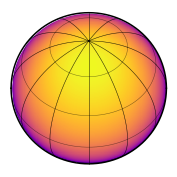

In [47]:
# Let's look at the star 
star.map.show()

NOW WE PLOT THE LIGHT CURVE


In [48]:
%%time
time = np.linspace(-0.2, 0.2, 1000)
flux_system = system.flux(time)

CPU times: user 895 ms, sys: 24.7 ms, total: 920 ms
Wall time: 1.07 s


Text(0, 0.5, 'Normalised flux')

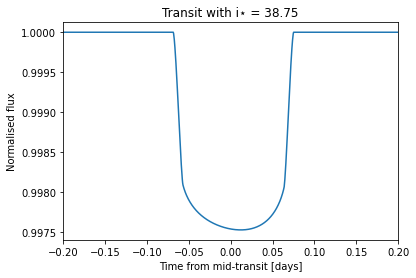

In [49]:
# plot model and data
plt.plot(time, flux_system)
plt.xlim(-0.2,0.2)
plt.title("Transit with i⋆ = 38.75");
plt.xlabel('Time from mid-transit [days]')
plt.ylabel('Normalised flux')

In [50]:
# Do some calculations to obtain polar and equatorial radius, 
# and the projected radii also (allowing for inclination of the star)

f_obl = star.map.f
host_rotinc = star.map.inc
host_radius = star.r

requator = host_radius*((1.0-f_obl)**(-1.0/3.0))
rpole = host_radius*((1.0-f_obl)**(2.0/3.0))
print(host_radius,requator,rpole)

host_inc_rad = np.radians(host_rotinc)
fprime = 1.0 - np.sqrt(((1.0 - f_obl)**2.0) * (np.sin(host_inc_rad)**2.0) + (np.cos(host_inc_rad)**2.0))

requ_p = host_radius*((1.0-fprime)**(-1.0/3.0))
rpol_p = host_radius*((1.0-fprime)**(2.0/3.0))

print(host_radius,requ_p,rpol_p)

2.075 2.125806765391082 1.977000291813706
2.075 2.093892508895899 2.03772482702484


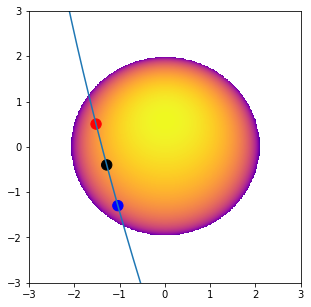

In [51]:
# Plot the star with the orbit projection
x, y, z = system.position(time)

fig, ax = plt.subplots(1, figsize=(5, 5))
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.axis("on")
ax.imshow(star.map.render(), origin="lower", cmap="plasma", 
          extent=(-requ_p, requ_p, -rpol_p, rpol_p))

#set the planet radius as needed
ro = 0.1144

# add the orbital path
ax.plot(x[1], y[1])

#plot the planet as filled blue circle
circ = plt.Circle(
    (x[1][400], y[1][400]),
     radius=ro, 
     color="b", fill=True, clip_on=False, alpha=1.0
)
ax.add_patch(circ)

#plot the planet as filled circle
circ = plt.Circle(
    (x[1][500], y[1][500]),
     radius=ro, 
     color="k", fill=True, clip_on=False, alpha=1.0
)
ax.add_patch(circ)

#and again as a red circle
circ = plt.Circle(
    (x[1][600], y[1][600]),
     radius=ro, 
     color="r", fill=True, clip_on=False, alpha=1.0
)
ax.add_patch(circ)


BLUE ---> TOWARDS US
RED ---> AWAY FROM US

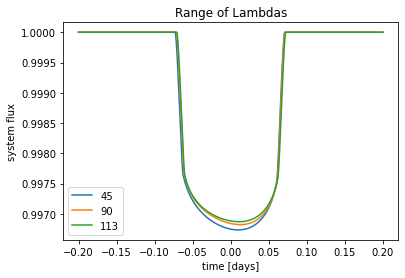

In [11]:
#Parameters i* = 35 and f* = 0.0800 from Cauley P. W. & Ahlers J. P. - 2022  

omegas = [45, 90, 113]

time = np.linspace(-0.20, 0.20, 1000)
fluxes = []

# Creating a star
star = starry.Primary(
    map = starry.Map(
        ydeg = 0,
        udeg = 2,
        oblate = True,
        gdeg = 4,
        tpole = 8595,   
        wav = 736,
    ),
    r = 1.858,         
    m = 1.890            
)
star.map[1] = 0.1870                         # limb-darkening u1
star.map[2] = 0.2672                         # limb-darkening u2
star.map.beta = 0.20                         # gravity-darkening parameter# gravity-darkening parameter
star.map.inc = 35.0                          # set the star-rotational inclination 
star.map.f = 0.0800                          # oblatness (~ 0.330 limit)


# set default spin-orbit misalignment
planet.Omega = 0.0

for i in range(len(omegas)):
    planet = starry.Secondary(
        map = starry.Map(
            ydeg=0,
            amp=0,
            m=0,
        ),
        Omega = omegas[i],
        inc = 95.50,      # this is orbital inclination in degrees (impact parameter) (98-up to 82 down)
        porb = 2.744,     # orbital period in days
        r = 0.099,        # planet radius, in stellar radii = Rp/R*
        m = 0.01,         # planet mass -- this should not matter, but it must be set!
        t0 = +0.00,       # timing adjustment, to allow for changing mid-transit time
)
    
    system = starry.System(
        star,
        planet
    )

    fluxes.append(system.flux(time))

params = omegas
for i in range(len(params)):

    plt.plot(time, fluxes[i],label=params[i])
    plt.xlabel("time [days]")
    plt.ylabel("system flux")
    plt.legend()
    plt.title("Range of Lambdas"); 

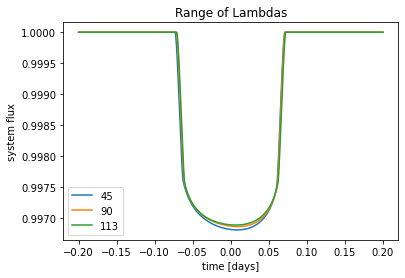

In [12]:
# Parameters i* = 55 and f* = 0.0369 from my excel

omegas = [45, 90, 113]

time = np.linspace(-0.20, 0.20, 1000)
fluxes = []

# Creating a star
star = starry.Primary(
    map = starry.Map(
        ydeg = 0,
        udeg = 2,
        oblate = True,
        gdeg = 4,
        tpole = 8525.8, 
        wav = 736,
    ),
    r = 1.858,         
    m = 1.890            
)
star.map[1] = 0.1870                         # limb-darkening u1
star.map[2] = 0.2672                         # limb-darkening u2
star.map.beta = 0.24                         # gravity-darkening parameter# gravity-darkening parameter
star.map.inc = 55.0                          # set the star-rotational inclination 
star.map.f = 0.0369                          # oblatness (~ 0.330 limit)


# set default spin-orbit misalignment
planet.Omega = 0.0

for i in range(len(omegas)):
    planet = starry.Secondary(
        map = starry.Map(
            ydeg=0,
            amp=0,
            m=0,
        ),
        Omega = omegas[i],
        inc = 95.50,      # this is orbital inclination in degrees (impact parameter) (98-up to 82 down)
        porb = 2.744,     # orbital period in days
        r = 0.099,        # planet radius, in stellar radii = Rp/R*
        m = 0.01,         # planet mass -- this should not matter, but it must be set!
        t0 = +0.00,       # timing adjustment, to allow for changing mid-transit time
)
    
    system = starry.System(
        star,
        planet
    )

    fluxes.append(system.flux(time))

params = omegas
for i in range(len(params)):

    plt.plot(time, fluxes[i],label=params[i])
    plt.xlabel("time [days]")
    plt.ylabel("system flux")
    plt.legend()
    plt.title("Range of Lambdas"); 

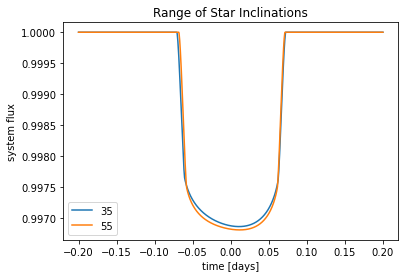

In [13]:
# Parameters i* = 35 and f* = 0.0800

incls =[35, 55]

time = np.linspace(-0.20, 0.20, 1000)
fluxes = []

star = starry.Primary(
    map = starry.Map(
        ydeg = 0,
        udeg = 2,
        oblate = True,
        gdeg = 4,
        tpole = 8595, #8526 or 8595 
        wav = 736,
    ),
    r = 1.858,         
    m = 1.890            
)
star.map[1] = 0.1870                         # limb-darkening u1
star.map[2] = 0.2672                         # limb-darkening u2
star.map.beta = 0.20 #0.24 or 0.23           # gravity-darkening parameter# gravity-darkening parameter
star.map.inc = 35 #55 or #35                 # set the star-rotational inclination 
star.map.f = 0.0800 #0.0369 or 0.0724        # oblatness (~ 0.330 limit)

# set default spin-orbit misalignment
planet.Omega = 0.0

for i in range(len(incls)):
    star.map.inc = incls[i]
    planet = starry.Secondary(
        map = starry.Map(
            ydeg=0,
            amp=0,
            m=0,
        ),
        Omega = 113,
        inc = 95.50,      # this is orbital inclination in degrees (impact parameter) (98-up to 82 down)
        porb = 2.744,     # orbital period in days
        r = 0.099,        # planet radius, in stellar radii = Rp/R*
        m = 0.01,         # planet mass -- this should not matter, but it must be set!
        t0 = +0.00,       # timing adjustment, to allow for changing mid-transit time

    )
    
    system = starry.System(
        star,
        planet
    )

    fluxes.append(system.flux(time))

params = incls
for i in range(len(params)):

    plt.plot(time, fluxes[i],label=params[i])
    plt.xlabel("time [days]")
    plt.ylabel("system flux")
    plt.legend()
    plt.title("Range of Star Inclinations");

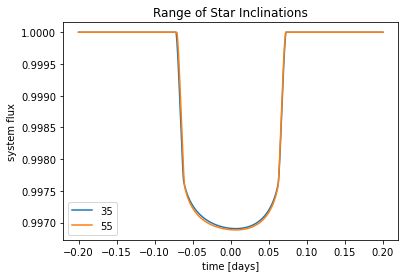

In [14]:
# Parameters i* = 55 and f* = 0.0369

incls =[35, 55]

time = np.linspace(-0.20, 0.20, 1000)
fluxes = []

star = starry.Primary(
    map = starry.Map(
        ydeg = 0,
        udeg = 2,
        oblate = True,
        gdeg = 4,
        tpole = 8525.8, 
        wav = 736,
    ),
    r = 1.858,         
    m = 1.890            
)
star.map[1] = 0.1870                         # limb-darkening u1
star.map[2] = 0.2672                         # limb-darkening u2
star.map.beta = 0.24                         # gravity-darkening parameter# gravity-darkening parameter
star.map.inc = 55                            # set the star-rotational inclination 
star.map.f = 0.0369                          # oblatness (~ 0.330 limit)

# set default spin-orbit misalignment
planet.Omega = 0.0

for i in range(len(incls)):
    star.map.inc = incls[i]
    planet = starry.Secondary(
        map = starry.Map(
            ydeg=0,
            amp=0,
            m=0,
        ),
        Omega = 113,
        inc = 95.50,      # this is orbital inclination in degrees (impact parameter) (98-up to 82 down)
        porb = 2.744,     # orbital period in days
        r = 0.099,        # planet radius, in stellar radii = Rp/R*
        m = 0.01,         # planet mass -- this should not matter, but it must be set!
        t0 = +0.00,       # timing adjustment, to allow for changing mid-transit time

    )
    
    system = starry.System(
        star,
        planet
    )

    fluxes.append(system.flux(time))

params = incls
for i in range(len(params)):

    plt.plot(time, fluxes[i],label=params[i])
    plt.xlabel("time [days]")
    plt.ylabel("system flux")
    plt.legend()
    plt.title("Range of Star Inclinations");

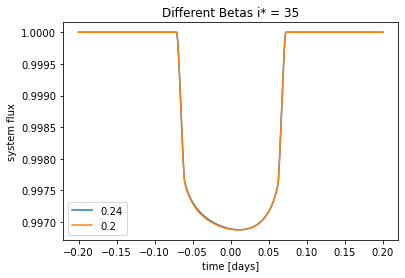

In [15]:
# Parameters i* = 35 and f* = 0.0800

betas =[0.24, 0.20]

time = np.linspace(-0.20, 0.20, 1000)
fluxes = []

star = starry.Primary(
    map = starry.Map(
        ydeg = 0,
        udeg = 2,
        oblate = True,
        gdeg = 4,
        tpole = 8595,  
        wav = 736,
    ),
    r = 1.858,         
    m = 1.890            
)
star.map[1] = 0.1870                         # limb-darkening u1
star.map[2] = 0.2672                         # limb-darkening u2
star.map.beta = 0.20                         # gravity-darkening parameter# gravity-darkening parameter
star.map.inc = 35                            # set the star-rotational inclination 
star.map.f = 0.0724                          # oblatness (~ 0.330 limit)

# set default spin-orbit misalignment
planet.Omega = 0.0

for i in range(len(betas)):
    star.map.beta = betas[i]
    planet = starry.Secondary(
        map = starry.Map(
            ydeg=0,
            amp=0,
            m=0,
        ),
        Omega = 113,
        inc = 95.50,      # this is orbital inclination in degrees (impact parameter) (98-up to 82 down)
        porb = 2.744,     # orbital period in days
        r = 0.099,        # planet radius, in stellar radii = Rp/R*
        m = 0.01,         # planet mass -- this should not matter, but it must be set!
        t0 = +0.00,       # timing adjustment, to allow for changing mid-transit time

    )
    
    system = starry.System(
        star,
        planet
    )

    fluxes.append(system.flux(time))

params = betas
for i in range(len(params)):

    plt.plot(time, fluxes[i],label=params[i])
    plt.xlabel("time [days]")
    plt.ylabel("system flux")
    plt.legend()
    plt.title("Different Betas i* = 35");

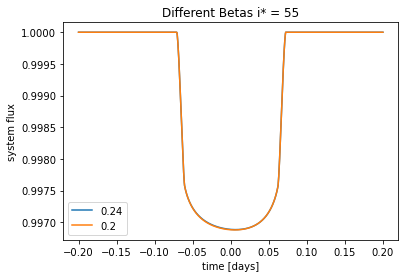

In [16]:
# Parameters i* = 55 and f* = 0.0369

betas =[0.24, 0.20]

time = np.linspace(-0.20, 0.20, 1000)
fluxes = []

star = starry.Primary(
    map = starry.Map(
        ydeg = 0,
        udeg = 2,
        oblate = True,
        gdeg = 4,
        tpole = 8525.8, 
        wav = 736,
    ),
    r = 1.858,         
    m = 1.890            
)
star.map[1] = 0.1870                         # limb-darkening u1
star.map[2] = 0.2672                         # limb-darkening u2
star.map.beta = 0.24                         # gravity-darkening parameter# gravity-darkening parameter
star.map.inc = 55                            # set the star-rotational inclination 
star.map.f = 0.0369                          # oblatness (~ 0.330 limit)

# set default spin-orbit misalignment
planet.Omega = 0.0

for i in range(len(betas)):
    star.map.beta = betas[i]
    planet = starry.Secondary(
        map = starry.Map(
            ydeg=0,
            amp=0,
            m=0,
        ),
        Omega = 113,
        inc = 95.50,      # this is orbital inclination in degrees (impact parameter) (98-up to 82 down)
        porb = 2.744,     # orbital period in days
        r = 0.099,        # planet radius, in stellar radii = Rp/R*
        m = 0.01,         # planet mass -- this should not matter, but it must be set!
        t0 = +0.00,       # timing adjustment, to allow for changing mid-transit time

    )
    
    system = starry.System(
        star,
        planet
    )

    fluxes.append(system.flux(time))

params = betas
for i in range(len(params)):

    plt.plot(time, fluxes[i],label=params[i])
    plt.xlabel("time [days]")
    plt.ylabel("system flux")
    plt.legend()
    plt.title("Different Betas i* = 55");